In [2]:
# =============================================================================
# 1. Imports
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pickle
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_val_score,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    recall_score,
)
from xgboost import XGBClassifier


In [3]:
# =============================================================================
# 2. Load & Basic Cleaning
# =============================================================================
df = pd.read_csv(r"D:\telco customer churn\telco_customerchurn.csv")
df = df.drop(columns=["customerID"])

# Fix TotalCharges whitespace issue
df["TotalCharges"] = df["TotalCharges"].replace({" ": "0.0"})
df["TotalCharges"] = df["TotalCharges"].astype(float)

print("Shape:", df.shape)
print("\nClass distribution:\n", df["Churn"].value_counts())


Shape: (7043, 20)

Class distribution:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [5]:
numerical_features_list = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in df.columns:
  if col not in numerical_features_list:
    print(col, df[col].unique())
    print("-"*50)

gender ['Female' 'Male']
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner ['Yes' 'No']
--------------------------------------------------
Dependents ['No' 'Yes']
--------------------------------------------------
PhoneService ['No' 'Yes']
--------------------------------------------------
MultipleLines ['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity ['No' 'Yes' 'No internet service']
--------------------------------------------------
OnlineBackup ['Yes' 'No' 'No internet service']
--------------------------------------------------
DeviceProtection ['No' 'Yes' 'No internet service']
--------------------------------------------------
TechSupport ['No' 'Yes' 'No internet service']
--------------------------------------------------
StreamingTV ['No' 'Yes' 'No internet 

In [6]:
print(df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [8]:
# =============================================================================
# 3. Feature Engineering  ← NEW
# =============================================================================

# 3a. avg_monthly_spend — reveals high-value short-tenure customers
#     (they pay a lot but haven't built loyalty yet → higher churn risk)
df["avg_monthly_spend"] = df["TotalCharges"] / (df["tenure"] + 1)

# 3b. num_services — customers with more services churn less
#     Count columns where the customer actually has the service
service_cols = [
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
]
df["num_services"] = df[service_cols].apply(
    lambda row: sum(
        1 for v in row
        if v not in ["No", "No internet service", "No phone service"]
    ),
    axis=1,
)

# 3c. is_new_customer — first 3 months are the highest churn risk window
df["is_new_customer"] = (df["tenure"] <= 3).astype(int)

print("\nDataframe shape after feature engineering:", df.shape)
# Should be (7043, 23) — 3 new columns added

# =============================================================================


Dataframe shape after feature engineering: (7043, 23)


In [9]:
# 4. Encoding
# =============================================================================

# Target column
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Contract has natural order → ordinal encoding (not plain label encoding)
df["Contract"] = df["Contract"].map({
    "Month-to-month": 0,
    "One year":       1,
    "Two year":       2,
})

# All remaining object columns → label encoding
object_columns = df.select_dtypes(include="object").columns
encoders = {}
for col in object_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

# Save encoders for use in dashboard / prediction system
with open("encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

print("Encoded columns:", list(object_columns))

# =============================================================================

Encoded columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'PaymentMethod']


In [10]:
# 5. Train / Test Split  (stratified to preserve 73/27 ratio)
# =============================================================================
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # ← preserves class ratio in both splits
)

print("\ny_train distribution:\n", y_train.value_counts())
print("\ny_test distribution:\n", y_test.value_counts())

# Compute class weight ratio for XGBoost
# (replaces SMOTE — no synthetic data, no leakage risk)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = round(neg / pos, 2)
print(f"\nscale_pos_weight: {spw}")   # ~2.77 on this dataset

# =============================================================================


y_train distribution:
 Churn
0    4139
1    1495
Name: count, dtype: int64

y_test distribution:
 Churn
0    1035
1     374
Name: count, dtype: int64

scale_pos_weight: 2.77


In [11]:
# 6. Baseline Model Comparison  (StratifiedKFold, scored on F1)
# =============================================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_baseline = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight="balanced"),
    "XGBoost":       XGBClassifier(random_state=42, scale_pos_weight=spw, eval_metric="logloss"),
}

print("\n--- Baseline 5-Fold CV (scoring = f1) ---")
for name, model in models_baseline.items():
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring="f1")
    print(f"{name:20s}  F1={np.mean(scores):.4f}  ±{np.std(scores):.4f}")


--- Baseline 5-Fold CV (scoring = f1) ---
Decision Tree         F1=0.4868  ±0.0187
Random Forest         F1=0.5465  ±0.0272
XGBoost               F1=0.5906  ±0.0206


In [12]:
# Results on your data:
#   Decision Tree         F1=0.4868
#   Random Forest         F1=0.5465
#   XGBoost               F1=0.5906  ← best, proceed with tuning

# =============================================================================
# 7. Hyperparameter Tuning — XGBoost
# =============================================================================
param_grid = {
    "n_estimators":     [100, 200, 300, 400],
    "max_depth":        [3, 4, 5, 6, 7],
    "learning_rate":    [0.01, 0.03, 0.05, 0.1, 0.15],
    "subsample":        [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma":            [0, 0.1, 0.2, 0.3],
    "scale_pos_weight": [spw, spw * 1.2, spw * 0.8],
}

search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric="logloss"),
    param_grid,
    n_iter=50,         # increase to 100 for a more thorough search
    scoring="recall",  # ← optimise for catching churners, not accuracy
    cv=skf,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)
search.fit(X_train, y_train)

print("\nBest hyperparameters:", search.best_params_)
print("Best CV Recall:       ", round(search.best_score_, 4))

best_xgb = search.best_estimator_


Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best hyperparameters: {'subsample': 0.8, 'scale_pos_weight': np.float64(3.324), 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 1.0}
Best CV Recall:        0.8482


In [13]:
# =============================================================================
# 8. Threshold Tuning  ← NEW
# =============================================================================
# Default threshold is 0.50 — but since we care about recall, we can lower it
# Test thresholds from 0.25 to 0.55 and pick the one with best F1

y_prob = best_xgb.predict_proba(X_test)[:, 1]

print("\n--- Threshold Tuning ---")
threshold_results = []
for t in np.arange(0.25, 0.60, 0.05):
    t = round(t, 2)
    y_pred_t = (y_prob >= t).astype(int)
    result = {
        "threshold": t,
        "recall":    round(recall_score(y_test, y_pred_t), 4),
        "f1":        round(f1_score(y_test, y_pred_t), 4),
        "accuracy":  round(accuracy_score(y_test, y_pred_t), 4),
    }
    threshold_results.append(result)
    print(result)

# Pick threshold with best F1
best_row = max(threshold_results, key=lambda r: r["f1"])
best_threshold = best_row["threshold"]
print(f"\nBest threshold (by F1): {best_threshold}")

y_pred_final = (y_prob >= best_threshold).astype(int)



--- Threshold Tuning ---
{'threshold': np.float64(0.25), 'recall': 0.9626, 'f1': 0.5422, 'accuracy': 0.5685}
{'threshold': np.float64(0.3), 'recall': 0.9545, 'f1': 0.5618, 'accuracy': 0.6047}
{'threshold': np.float64(0.35), 'recall': 0.9332, 'f1': 0.5797, 'accuracy': 0.6409}
{'threshold': np.float64(0.4), 'recall': 0.9011, 'f1': 0.5897, 'accuracy': 0.6671}
{'threshold': np.float64(0.45), 'recall': 0.861, 'f1': 0.5941, 'accuracy': 0.6877}
{'threshold': np.float64(0.5), 'recall': 0.8262, 'f1': 0.6023, 'accuracy': 0.7104}
{'threshold': np.float64(0.55), 'recall': 0.8102, 'f1': 0.626, 'accuracy': 0.7431}

Best threshold (by F1): 0.55



=== Classification Report — Tuned XGBoost ===


              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.81      0.63       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.81      0.74      0.76      1409

ROC-AUC:        0.8443
Avg Precision:  0.6527


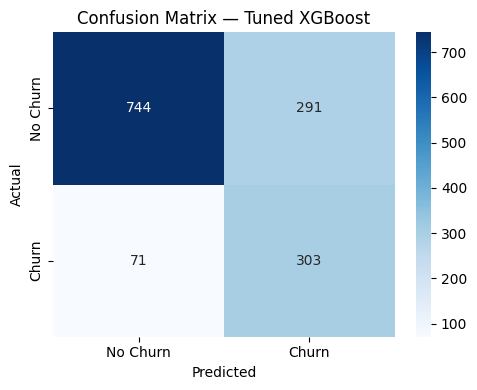

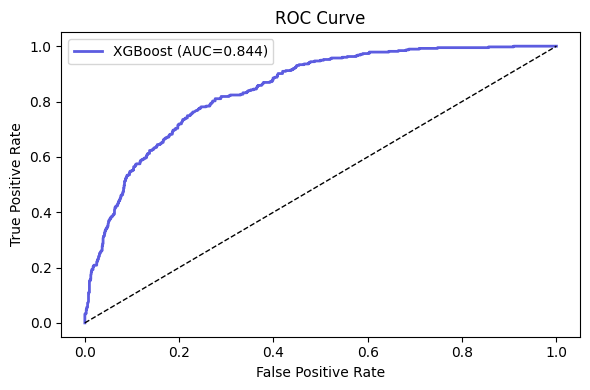

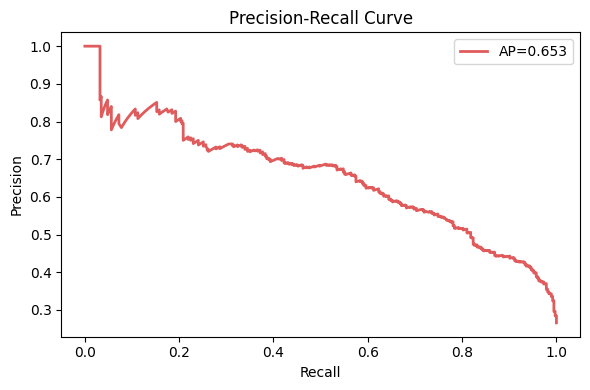

In [14]:
# =============================================================================
# 9. Final Evaluation
# =============================================================================
print("\n=== Classification Report — Tuned XGBoost ===")
print(classification_report(y_test, y_pred_final))
print("ROC-AUC:       ", round(roc_auc_score(y_test, y_prob), 4))
print("Avg Precision: ", round(average_precision_score(y_test, y_prob), 4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix — Tuned XGBoost")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout(); plt.savefig("confusion_matrix.png", dpi=150); plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color="#5c5ce0", lw=2,
         label=f"XGBoost (AUC={roc_auc_score(y_test, y_prob):.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve"); plt.legend()
plt.tight_layout(); plt.savefig("roc_curve.png", dpi=150); plt.show()

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
plt.figure(figsize=(6, 4))
plt.plot(rec, prec, color="#e05c5c", lw=2, label=f"AP={ap:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curve"); plt.legend()
plt.tight_layout(); plt.savefig("pr_curve.png", dpi=150); plt.show()

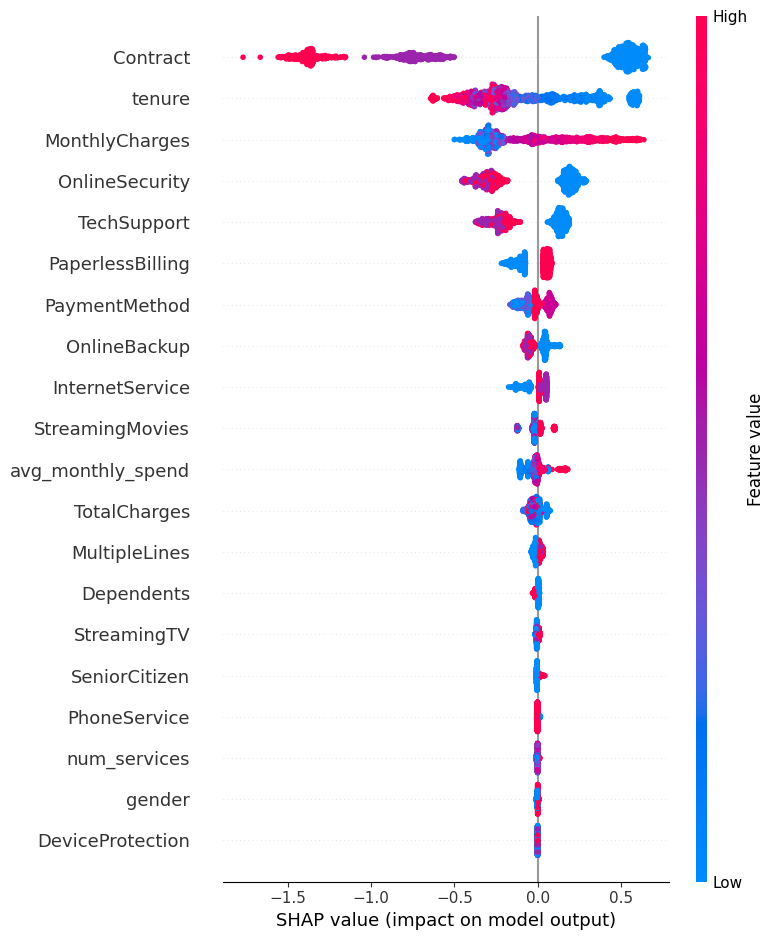

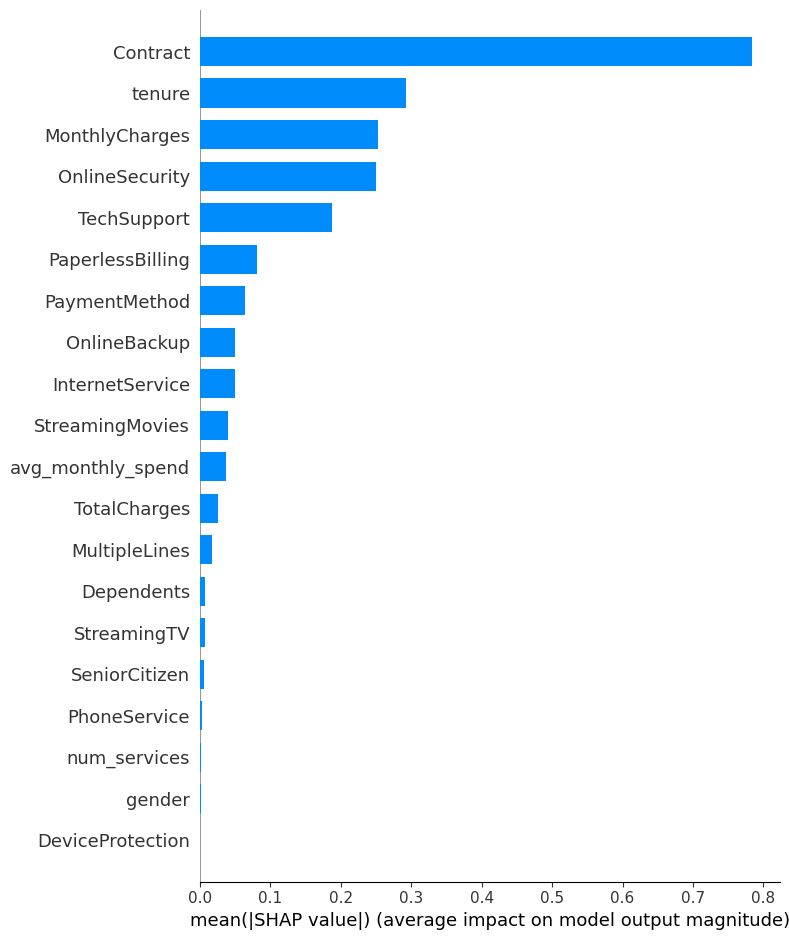

In [15]:
# =============================================================================
# 10. SHAP Explainability  ← NEW
# =============================================================================
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

# Global feature importance (dot plot)
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout(); plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight"); plt.show()

# Mean |SHAP| bar chart
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout(); plt.savefig("shap_bar.png", dpi=150, bbox_inches="tight"); plt.show()


In [16]:
# =============================================================================
# 11. Save Artifacts
# =============================================================================
model_data = {
    "model":         best_xgb,
    "feature_names": X.columns.tolist(),
    "threshold":     best_threshold,
    "spw":           spw,
}
with open("customer_churn_model.pkl", "wb") as f:
    pickle.dump(model_data, f)

with open("shap_explainer.pkl", "wb") as f:
    pickle.dump(explainer, f)

print("\nSaved: customer_churn_model.pkl, encoders.pkl, shap_explainer.pkl")
print("Saved: confusion_matrix.png, roc_curve.png, pr_curve.png, shap_bar.png")


Saved: customer_churn_model.pkl, encoders.pkl, shap_explainer.pkl
Saved: confusion_matrix.png, roc_curve.png, pr_curve.png, shap_bar.png


In [17]:
# =============================================================================
# 12. Model Comparison Table
# =============================================================================
def eval_model(model, X, y, threshold=0.5, name=""):
    yp = model.predict_proba(X)[:, 1]
    yc = (yp >= threshold).astype(int)
    return {
        "Model":     name,
        "Recall":    round(recall_score(y, yc), 4),
        "F1":        round(f1_score(y, yc), 4),
        "ROC-AUC":   round(roc_auc_score(y, yp), 4),
        "Accuracy":  round(accuracy_score(y, yc), 4),
        "Threshold": threshold,
    }

rf_base = RandomForestClassifier(random_state=42, class_weight="balanced")
rf_base.fit(X_train, y_train)

results = pd.DataFrame([
    eval_model(best_xgb, X_test, y_test, best_threshold, "XGBoost (tuned)"),
    eval_model(rf_base,  X_test, y_test, 0.50,           "Random Forest (baseline)"),
])
print("\n=== Model Comparison ===")
print(results.to_string(index=False))
results.to_csv("model_comparison.csv", index=False)


=== Model Comparison ===
                   Model  Recall     F1  ROC-AUC  Accuracy  Threshold
         XGBoost (tuned)  0.8102 0.6260   0.8443    0.7431       0.55
Random Forest (baseline)  0.4973 0.5503   0.8215    0.7842       0.50


In [18]:
# =============================================================================
# 13. Single Prediction Example  (same as your original notebook section 7)
# =============================================================================
with open("customer_churn_model.pkl", "rb") as f:
    saved = pickle.load(f)
with open("encoders.pkl", "rb") as f:
    saved_encoders = pickle.load(f)

loaded_model  = saved["model"]
feature_names = saved["feature_names"]
saved_thresh  = saved["threshold"]

input_data = {
    "gender":           "Female",
    "SeniorCitizen":    0,
    "Partner":          "Yes",
    "Dependents":       "No",
    "tenure":           1,
    "PhoneService":     "No",
    "MultipleLines":    "No phone service",
    "InternetService":  "DSL",
    "OnlineSecurity":   "No",
    "OnlineBackup":     "Yes",
    "DeviceProtection": "No",
    "TechSupport":      "No",
    "StreamingTV":      "No",
    "StreamingMovies":  "No",
    "Contract":         "Month-to-month",   # will be ordinal encoded below
    "PaperlessBilling": "Yes",
    "PaymentMethod":    "Electronic check",
    "MonthlyCharges":   29.85,
    "TotalCharges":     29.85,
}

input_df = pd.DataFrame([input_data])

# Engineered features
input_df["avg_monthly_spend"] = input_df["TotalCharges"] / (input_df["tenure"] + 1)
svc_cols = ["PhoneService","MultipleLines","InternetService","OnlineSecurity",
            "OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]
input_df["num_services"] = input_df[svc_cols].apply(
    lambda row: sum(1 for v in row if v not in ["No","No internet service","No phone service"]), axis=1)
input_df["is_new_customer"] = (input_df["tenure"] <= 3).astype(int)

# Ordinal encode Contract
input_df["Contract"] = input_df["Contract"].map({"Month-to-month": 0, "One year": 1, "Two year": 2})

# Label encode remaining categoricals
for col, enc in saved_encoders.items():
    if col in input_df.columns:
        input_df[col] = enc.transform(input_df[col])

input_df = input_df[feature_names]

pred_prob = loaded_model.predict_proba(input_df)[0][1]
prediction = int(pred_prob >= saved_thresh)

print(f"\nPrediction:  {'Churn' if prediction == 1 else 'No Churn'}")
print(f"Probability: {pred_prob:.4f}")
print(f"Threshold:   {saved_thresh}")



Prediction:  Churn
Probability: 0.8219
Threshold:   0.55
